<a href="https://www.kaggle.com/code/yanakutyshenko/notebook32c1bbb4fa?scriptVersionId=355856982" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [29]:
import os

data_dir = "/kaggle/input/datasets/yapwh1208/cats-breed-dataset/cat_v1"

print("Классы:")

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        print(class_name, "-", len(os.listdir(class_path)), "изображений")

Классы:
domestic_shorthair - 170 изображений
ragdoll - 207 изображений
siamese - 208 изображений
bengal - 177 изображений
maine_coon - 191 изображений


In [30]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [31]:
from torchvision.datasets import ImageFolder

dataset = ImageFolder(
    root=data_dir,
    transform=train_transform
)

print("Классы:", dataset.classes)
print("Количество изображений:", len(dataset))

Классы: ['bengal', 'domestic_shorthair', 'maine_coon', 'ragdoll', 'siamese']
Количество изображений: 952


In [32]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

print("Train:", len(train_dataset))
print("Test:", len(test_dataset))

Train: 761
Test: 191


In [33]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 24
Test batches: 6


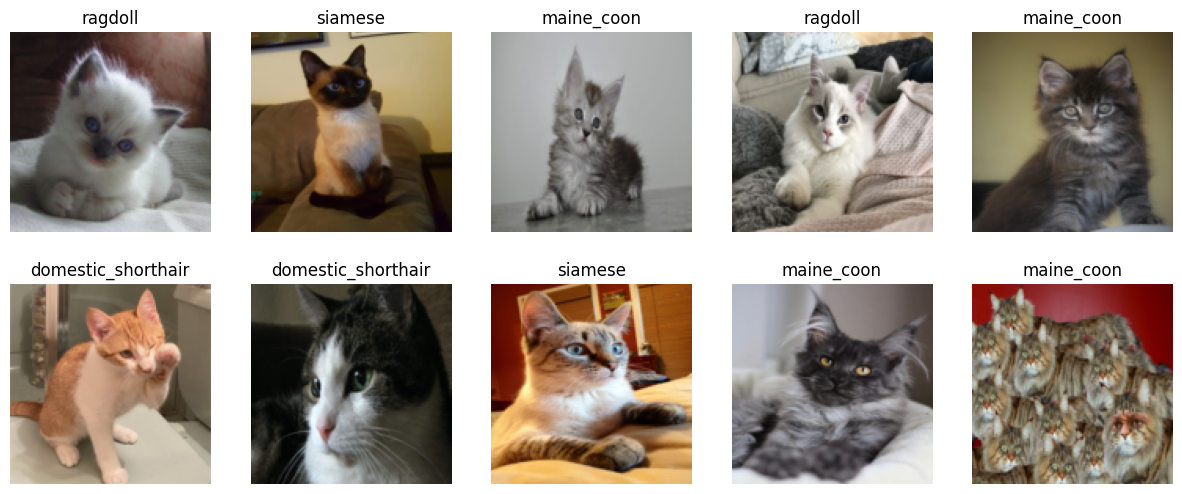

In [34]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    image = images[i].permute(1, 2, 0)

    ax.imshow(image)
    ax.set_title(dataset.classes[labels[i]])
    ax.axis("off")

plt.show()

In [35]:
print("Размер batch изображений:", images.shape)
print("Размер batch labels:", labels.shape)
print("Классы:", dataset.classes)

Размер batch изображений: torch.Size([32, 3, 128, 128])
Размер batch labels: torch.Size([32])
Классы: ['bengal', 'domestic_shorthair', 'maine_coon', 'ragdoll', 'siamese']


****Нове завдання****

In [36]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 24
Test batches: 6


In [37]:
import torch
import torch.nn as nn

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3 * 128 * 128, 512),
    nn.ReLU(),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Linear(128, 5)
)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=49152, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=5, bias=True)
)


In [38]:
images, labels = next(iter(train_loader))

output = model(images)

print("Размер входу:", images.shape)
print("Розмір виходу:", output.shape)

Размер входу: torch.Size([32, 3, 128, 128])
Розмір виходу: torch.Size([32, 5])


In [39]:
softmax = nn.Softmax(dim=1)

probabilities = softmax(output)

print(probabilities[0])
print("Сума ймовірностей:", probabilities[0].sum())

tensor([0.1996, 0.1912, 0.1933, 0.2086, 0.2073], grad_fn=<SelectBackward0>)
Сума ймовірностей: tensor(1.0000, grad_fn=<SumBackward0>)


In [40]:
loss_function = nn.CrossEntropyLoss()

print(loss_function)

CrossEntropyLoss()


In [41]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [42]:
images, labels = next(iter(train_loader))

optimizer.zero_grad()

output = model(images)

loss = loss_function(output, labels)

loss.backward()

optimizer.step()

print("Помилка:", loss.item())

Помилка: 1.6104919910430908


In [43]:
epochs = 10

for epoch in range(epochs):
    model.train()

    for images, labels in train_loader:
        optimizer.zero_grad()

        output = model(images)

        loss = loss_function(output, labels)

        loss.backward()

        optimizer.step()

    print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 1/10, Loss: 2.4763
Epoch 2/10, Loss: 1.8038
Epoch 3/10, Loss: 1.6374
Epoch 4/10, Loss: 1.7687
Epoch 5/10, Loss: 1.5351
Epoch 6/10, Loss: 1.3290
Epoch 7/10, Loss: 1.7893
Epoch 8/10, Loss: 1.4351
Epoch 9/10, Loss: 1.6000
Epoch 10/10, Loss: 1.6724


In [44]:
train_losses = []
test_losses = []

epochs = 10

for epoch in range(epochs):
    model.train()

    train_loss = 0

    for images, labels in train_loader:
        optimizer.zero_grad()

        output = model(images)

        loss = loss_function(output, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss = train_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()

    test_loss = 0

    with torch.no_grad():
        for images, labels in test_loader:
            output = model(images)

            loss = loss_function(output, labels)

            test_loss += loss.item()

    test_loss = test_loss / len(test_loader)
    test_losses.append(test_loss)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Test Loss: {test_loss:.4f}"
    )

Epoch 1/10 | Train Loss: 1.4375 | Test Loss: 1.5609
Epoch 2/10 | Train Loss: 1.4387 | Test Loss: 1.6117
Epoch 3/10 | Train Loss: 1.4271 | Test Loss: 1.5974
Epoch 4/10 | Train Loss: 1.4213 | Test Loss: 1.5732
Epoch 5/10 | Train Loss: 1.3732 | Test Loss: 1.5972
Epoch 6/10 | Train Loss: 1.3889 | Test Loss: 1.5990
Epoch 7/10 | Train Loss: 1.4213 | Test Loss: 1.6419
Epoch 8/10 | Train Loss: 1.4406 | Test Loss: 1.5649
Epoch 9/10 | Train Loss: 1.3399 | Test Loss: 1.6001
Epoch 10/10 | Train Loss: 1.3723 | Test Loss: 1.5843


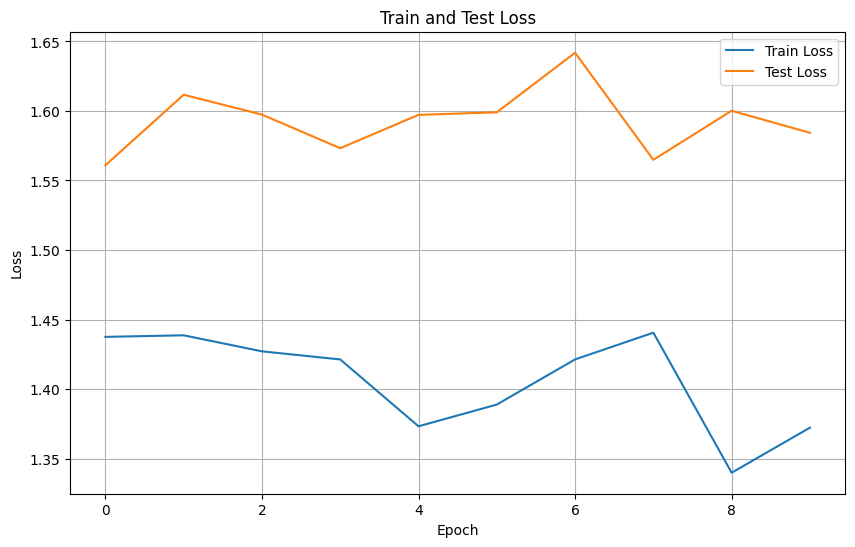

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train and Test Loss")

plt.legend()
plt.grid()

plt.show()

In [46]:
model.eval()

images, labels = next(iter(test_loader))

with torch.no_grad():
    output = model(images)
    probabilities = nn.Softmax(dim=1)(output)

print("Ймовірності першого зображення:")
print(probabilities[0])

print("Сума:")
print(probabilities[0].sum())

Ймовірності першого зображення:
tensor([0.1079, 0.0875, 0.5158, 0.1155, 0.1733])
Сума:
tensor(1.0000)


In [47]:
prediction = probabilities[0].argmax().item()
real_label = labels[0].item()

print("Предсказанный класс:", dataset.classes[prediction])
print("Настоящий класс:", dataset.classes[real_label])

Предсказанный класс: maine_coon
Настоящий класс: maine_coon


****Last task****

In [48]:
import torch
import torch.nn as nn

model = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, padding="same"),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(32, 64, kernel_size=3, padding="same"),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),
    nn.Linear(64 * 32 * 32, 128),
    nn.ReLU(),
    nn.Linear(128, 5)
)

print(model)

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=65536, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=5, bias=True)
)


In [49]:
images, labels = next(iter(train_loader))

output = model(images)

print("Размер входу:", images.shape)
print("Розмір виходу:", output.shape)

Размер входу: torch.Size([32, 3, 128, 128])
Розмір виходу: torch.Size([32, 5])


In [50]:
loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(loss_function)
print(optimizer)

CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [51]:
train_losses = []
test_losses = []

epochs = 10

for epoch in range(epochs):
    model.train()

    train_loss = 0

    for images, labels in train_loader:
        optimizer.zero_grad()

        output = model(images)

        loss = loss_function(output, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss = train_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()

    test_loss = 0

    with torch.no_grad():
        for images, labels in test_loader:
            output = model(images)

            loss = loss_function(output, labels)

            test_loss += loss.item()

    test_loss = test_loss / len(test_loader)
    test_losses.append(test_loss)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Test Loss: {test_loss:.4f}"
    )

Epoch 1/10 | Train Loss: 1.7564 | Test Loss: 1.6078
Epoch 2/10 | Train Loss: 1.6075 | Test Loss: 1.5895
Epoch 3/10 | Train Loss: 1.5814 | Test Loss: 1.5248
Epoch 4/10 | Train Loss: 1.4941 | Test Loss: 1.4140
Epoch 5/10 | Train Loss: 1.3820 | Test Loss: 1.3457
Epoch 6/10 | Train Loss: 1.2888 | Test Loss: 1.2933
Epoch 7/10 | Train Loss: 1.2760 | Test Loss: 1.3089
Epoch 8/10 | Train Loss: 1.2742 | Test Loss: 1.3487
Epoch 9/10 | Train Loss: 1.1612 | Test Loss: 1.2636
Epoch 10/10 | Train Loss: 1.1097 | Test Loss: 1.2485


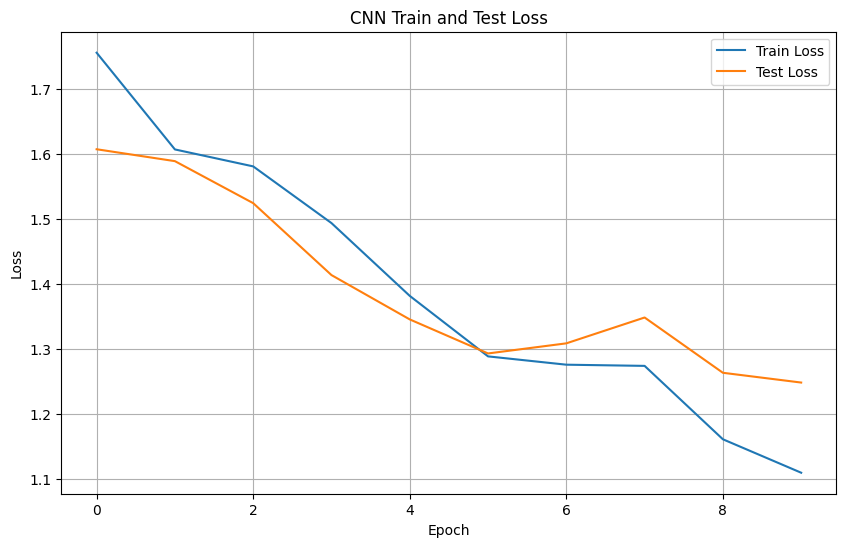

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Train and Test Loss")

plt.legend()
plt.grid()

plt.show()

In [53]:
model.eval()

images, labels = next(iter(test_loader))

with torch.no_grad():
    output = model(images)
    probabilities = nn.Softmax(dim=1)(output)

print("Ймовірності першого зображення:")
print(probabilities[0])

print("Сума:")
print(probabilities[0].sum())

Ймовірності першого зображення:
tensor([0.5044, 0.0609, 0.4082, 0.0073, 0.0192])
Сума:
tensor(1.0000)


In [54]:
prediction = probabilities[0].argmax().item()
real_label = labels[0].item()

print("Предсказанный класс:", dataset.classes[prediction])
print("Настоящий класс:", dataset.classes[real_label])

Предсказанный класс: bengal
Настоящий класс: maine_coon
